In [ ]:
import os
import numpy as np
import qutip as qt
from quantumScarFunctions import *

In [14]:
N = 4
wd = 0.6365091993031
wm = 1.0
freq_dis = 0.00
indv_qubit = False
t_max = 200
tlist = np.linspace(0, t_max, 400)
reals = 100
rand = True
z_ham = False
dis = 0.3

In [ ]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
full_scar = 0
for _ in range(reals):
    H0_dis, eigenvalues_dis, eigenstates_dis = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=False)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0_dis, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0_dis])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
xfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)
full_qubit = 0 
for _ in range(reals):
    qH0_dis, qeigenvalues_dis, qeigenstates_dis = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx], fixed_seed=False)
    qbandwidth = qeigenvalues_dis[-1] - qeigenvalues_dis[0]

    qH = qt.QobjEvo([qH0_dis, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0_dis])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit
xfull_qubit = full_qubit / reals

In [16]:
dz = 0.0
dy = dis
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
full_scar = 0
for _ in range(reals):
    H0_dis, eigenvalues_dis, eigenstates_dis = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=False)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0_dis, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0_dis])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
yfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)
full_qubit = 0
for _ in range(reals):
    qH0_dis, qeigenvalues_dis, qeigenstates_dis = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx], fixed_seed=False)
    qbandwidth = qeigenvalues_dis[-1] - qeigenvalues_dis[0]

    qH = qt.QobjEvo([qH0_dis, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0_dis])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit
yfull_qubit = full_qubit / reals

In [17]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
full_scar = 0
for _ in range(reals):
    H0_dis, eigenvalues_dis, eigenstates_dis = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=False)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0_dis, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0_dis])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
zfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)
full_qubit = 0
for _ in range(reals):
    qH0_dis, qeigenvalues_dis, qeigenstates_dis = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx], fixed_seed=False)
    qbandwidth = qeigenvalues_dis[-1] - qeigenvalues_dis[0]

    qH = qt.QobjEvo([qH0_dis, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0_dis])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit
zfull_qubit = full_qubit / reals

In [ ]:
data = []
data.append(xfull_scar)
data.append(yfull_scar)
data.append(zfull_scar)
data.append(xfull_qubit) 
data.append(yfull_qubit)
data.append(zfull_qubit)
data = np.array(data)

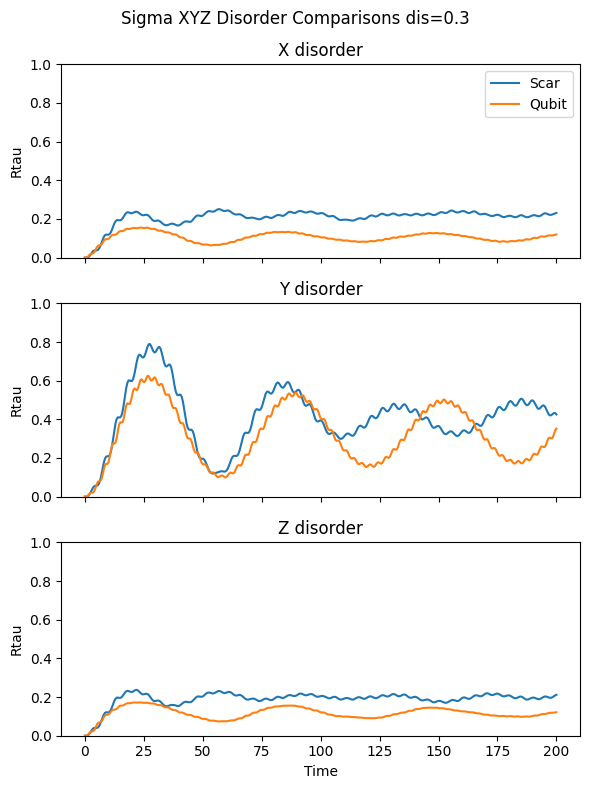

<Figure size 640x480 with 0 Axes>

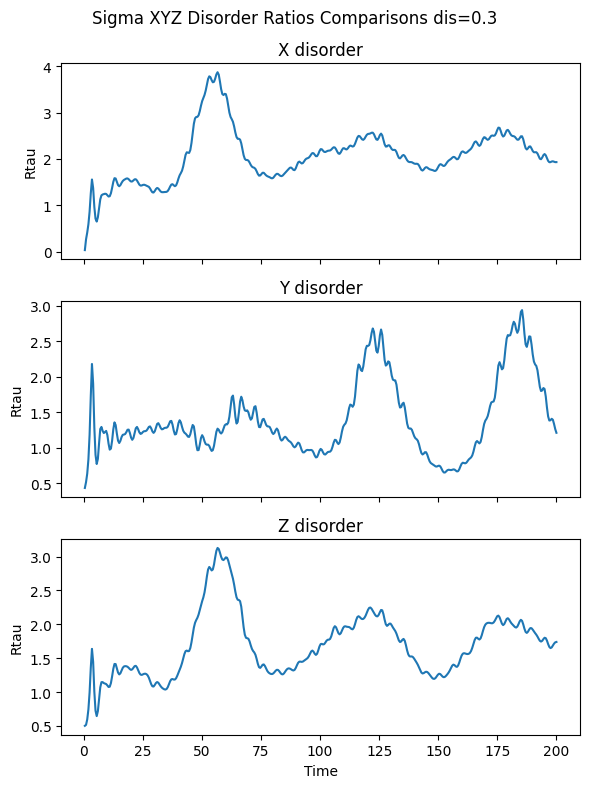

In [18]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Comparisons dis=0.3")

axs[0].plot(tlist, xfull_scar, label="Scar")
axs[0].plot(tlist, xfull_qubit, label="Qubit")
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")
axs[0].legend()

axs[1].plot(tlist, yfull_scar, label="Scar")
axs[1].plot(tlist, yfull_qubit, label="Qubit")
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist, zfull_scar, label="Scar")
axs[2].plot(tlist, zfull_qubit, label="Qubit")
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Ratios Comparisons dis=0.3")

axs[0].plot(tlist[1:], xfull_scar[1:] / xfull_qubit[1:])
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")

axs[1].plot(tlist[1:], yfull_scar[1:] / yfull_qubit[1:])
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist[1:], zfull_scar[1:] / zfull_qubit[1:])
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

plt.tight_layout()
plt.show()